# Imports and Data Loading

In [1]:
import os
import gc
import json
import random
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label as nd_label

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import (
    wide_resnet50_2,
    Wide_ResNet50_2_Weights,
)


# Reproducibility & Multi-GPU Configuration (2x T4 Support)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# Check and display GPU details
num_gpus = torch.cuda.device_count()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version:     {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"Primary Device:      {device}")
print(f"Number of GPUs:      {num_gpus}")

if num_gpus > 0:
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        vram_gb = torch.cuda.get_device_properties(i).total_memory / (1024 ** 3)
        print(f"  GPU {i}: {gpu_name} ({vram_gb:.2f} GB VRAM)")
    if num_gpus >= 2:
        print("-> Multi-GPU setup detected: PyTorch DataParallel will be utilized across both GPUs.")
else:
    print("-> Warning: Running on CPU.")


PyTorch Version:     2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Primary Device:      cuda:0
Number of GPUs:      2
  GPU 0: Tesla T4 (14.56 GB VRAM)
  GPU 1: Tesla T4 (14.56 GB VRAM)
-> Multi-GPU setup detected: PyTorch DataParallel will be utilized across both GPUs.


# Dataset Download

In [2]:
# ==============================================================================
# Real-IAD: One-Time Download & Extraction
# Saves everything to /kaggle/working/Real-IAD
# ==============================================================================

import os
import zipfile
from pathlib import Path

try:
    from huggingface_hub import login, snapshot_download, hf_hub_download
except ImportError:
    os.system("pip install -q huggingface_hub")
    from huggingface_hub import login, snapshot_download, hf_hub_download


# ------------------------------------------------------------------------------
# 1. Authenticate with Hugging Face
# ------------------------------------------------------------------------------

from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

login(token=hf_token)

print("Hugging Face authentication successful.")


# ------------------------------------------------------------------------------
# 2. Paths
# ------------------------------------------------------------------------------

repo_id = "Real-IAD/Real-IAD"

dataset_path = Path("/kaggle/working/Real-IAD")
dataset_path.mkdir(parents=True, exist_ok=True)

image_dir = dataset_path / "realiad_512"
json_dir = dataset_path / "realiad_jsons_sv"


# ------------------------------------------------------------------------------
# 3. Download & extract JSON metadata
# ------------------------------------------------------------------------------

if json_dir.exists() and any(json_dir.glob("*.json")):
    print("JSON metadata already exists. Skipping download.")
else:
    print("Downloading realiad_jsons.zip...")

    json_zip = hf_hub_download(
        repo_id=repo_id,
        repo_type="dataset",
        filename="realiad_jsons.zip",
        local_dir=str(dataset_path)
    )

    print("Extracting JSON metadata...")

    with zipfile.ZipFile(json_zip, "r") as z:
        z.extractall(dataset_path)

    Path(json_zip).unlink(missing_ok=True)

    print("JSON metadata extracted.")


# ------------------------------------------------------------------------------
# 4. Download 512x512 images
# ------------------------------------------------------------------------------

if image_dir.exists() and any(image_dir.iterdir()):
    print("512x512 image directory already contains files.")
    print("Skipping image download.")
else:
    print("Downloading Real-IAD 512x512 images...")

    snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        allow_patterns=["realiad_512/**"],
        local_dir=str(dataset_path),
        local_dir_use_symlinks=False,
        max_workers=8
    )

    print("Image download complete.")


# ------------------------------------------------------------------------------
# 5. Extract category ZIPs
# ------------------------------------------------------------------------------

image_dir.mkdir(parents=True, exist_ok=True)

category_zips = sorted(image_dir.glob("*.zip"))

if category_zips:
    print(f"\nFound {len(category_zips)} category ZIP files.")

    for cat_zip in category_zips:
        cat_name = cat_zip.stem
        cat_out = image_dir / cat_name

        # Don't extract if category already exists
        if cat_out.exists() and any(cat_out.iterdir()):
            print(f"Skipping {cat_name}: already extracted.")
            cat_zip.unlink(missing_ok=True)
            continue

        print(f"Extracting {cat_zip.name}...")

        try:
            with zipfile.ZipFile(cat_zip, "r") as z:
                z.extractall(image_dir)

            # Delete ZIP immediately to save disk space
            cat_zip.unlink(missing_ok=True)

            print(f"  Done: {cat_name}")

        except Exception as e:
            print(f"  ERROR extracting {cat_zip.name}: {e}")

else:
    print("No category ZIP files found. They may already be extracted.")


# ------------------------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------------------------

categories = sorted([
    d.name
    for d in image_dir.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print("\n" + "=" * 70)
print("REAL-IAD DOWNLOAD SETUP COMPLETE")
print("=" * 70)

print(f"Image directory : {image_dir}")
print(f"JSON directory  : {json_dir}")
print(f"Categories      : {len(categories)}")
print(f"Categories      : {categories}")

Hugging Face authentication successful.


realiad_jsons.zip:   0%|          | 0.00/3.23M [00:00<?, ?B/s]

Extracting JSON metadata...
JSON metadata extracted.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Image download complete.

Found 30 category ZIP files.
Extracting audiojack.zip...
  Done: audiojack
Extracting bottle_cap.zip...
  Done: bottle_cap
Extracting button_battery.zip...
  Done: button_battery
Extracting end_cap.zip...
  Done: end_cap
Extracting eraser.zip...
  Done: eraser
Extracting fire_hood.zip...
  Done: fire_hood
Extracting mint.zip...
  Done: mint
Extracting mounts.zip...
  Done: mounts
Extracting pcb.zip...
  Done: pcb
Extracting phone_battery.zip...
  Done: phone_battery
Extracting plastic_nut.zip...
  Done: plastic_nut
Extracting plastic_plug.zip...
  Done: plastic_plug
Extracting porcelain_doll.zip...
  Done: porcelain_doll
Extracting regulator.zip...
  Done: regulator
Extracting rolled_strip_base.zip...
  Done: rolled_strip_base
Extracting sim_card_set.zip...
  Done: sim_card_set
Extracting switch.zip...
  Done: switch
Extracting tape.zip...
  Done: tape
Extracting terminalblock.zip...
  Done: terminalblock
Extracting toothbrush.zip...
  Done: toothbrush
Extract

In [3]:
# ==============================================================================
# Real-IAD: Session Initialization
# Does NOT download anything
# ==============================================================================

from pathlib import Path

dataset_path = Path("/kaggle/working/Real-IAD")

image_dir = dataset_path / "realiad_512"
json_dir = dataset_path / "realiad_jsons_sv"

if not image_dir.exists():
    raise FileNotFoundError(
        f"Image directory not found: {image_dir}\n"
        "Run the one-time download/extraction block first."
    )

if not json_dir.exists():
    raise FileNotFoundError(
        f"JSON directory not found: {json_dir}\n"
        "Run the one-time download/extraction block first."
    )

categories = sorted([
    d.name
    for d in image_dir.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print(f"Image directory : {image_dir}")
print(f"JSON directory  : {json_dir}")
print(f"Categories ({len(categories)}): {categories}")

Image directory : /kaggle/working/Real-IAD/realiad_512
JSON directory  : /kaggle/working/Real-IAD/realiad_jsons_sv
Categories (30): ['audiojack', 'bottle_cap', 'button_battery', 'end_cap', 'eraser', 'fire_hood', 'mint', 'mounts', 'pcb', 'phone_battery', 'plastic_nut', 'plastic_plug', 'porcelain_doll', 'regulator', 'rolled_strip_base', 'sim_card_set', 'switch', 'tape', 'terminalblock', 'toothbrush', 'toy', 'toy_brick', 'transistor1', 'u_block', 'usb', 'usb_adaptor', 'vcpill', 'wooden_beads', 'woodstick', 'zipper']


# Preprocessing

In [4]:
# Input resolution updated from 224 to 512 for Real-IAD
input_size = 512

normalize = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

image_transform = T.Compose([
    T.Resize((input_size, input_size)),
    T.ToTensor(),
    normalize,
])

mask_transform = T.Compose([
    T.Resize((input_size, input_size), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor(),
])

# Standard Real-IAD Dataset Classes (Memory-safe on-the-fly loading from disk)
class TrainDataset(Dataset):
    """
    Dataset for normal training samples.
    Loads image from disk on-the-fly to prevent CPU RAM overflow.
    """
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform if transform is not None else image_transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        item = self.images[idx]
        if isinstance(item, (str, Path)):
            with Image.open(item) as img:
                return self.transform(img.convert("RGB"))
        elif isinstance(item, dict):
            with Image.open(item["image_path"]) as img:
                return self.transform(img.convert("RGB"))
        return item


class TestDataset(Dataset):
    """
    Dataset for test samples (normal and defective) with ground-truth masks.
    """
    def __init__(self, images, labels, masks, img_transform=None, msk_transform=None):
        self.images = images
        self.labels = labels
        self.masks = masks
        self.img_transform = img_transform if img_transform is not None else image_transform
        self.msk_transform = msk_transform if msk_transform is not None else mask_transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_item = self.images[idx]
        if isinstance(img_item, (str, Path)):
            with Image.open(img_item) as img:
                img_tensor = self.img_transform(img.convert("RGB"))
        elif isinstance(img_item, dict):
            with Image.open(img_item["image_path"]) as img:
                img_tensor = self.img_transform(img.convert("RGB"))
        else:
            img_tensor = img_item

        label_item = self.labels[idx] if not isinstance(img_item, dict) else img_item["label"]

        mask_item = self.masks[idx] if not isinstance(img_item, dict) else img_item.get("mask_path")
        if mask_item and isinstance(mask_item, (str, Path)) and Path(mask_item).exists() and label_item == 1:
            with Image.open(mask_item) as msk:
                mask_tensor = self.msk_transform(msk.convert("L"))
                mask_tensor = (mask_tensor > 0.5).float()
        elif isinstance(mask_item, torch.Tensor):
            mask_tensor = mask_item
        else:
            mask_tensor = torch.zeros((1, input_size, input_size), dtype=torch.float32)

        return img_tensor, label_item, mask_tensor


def load_category_samples(category_name, image_root, json_root):
    """
    Load a single-view Real-IAD category using the official JSON structure.

    JSON structure:
        {
            "meta": {...},
            "train": [...],
            "test": [...]
        }

    Each sample contains:
        category
        anomaly_class
        image_path
        mask_path
    """
    json_file = json_root / f"{category_name}.json"

    if not json_file.exists():
        raise FileNotFoundError(
            f"Single-view JSON not found: {json_file}"
        )

    with open(json_file, "r") as f:
        meta = json.load(f)

    if not isinstance(meta, dict):
        raise ValueError(
            f"Unexpected JSON format in {json_file}: expected dict."
        )

    if "train" not in meta or "test" not in meta:
        raise ValueError(
            f"JSON missing train/test sections: {json_file}"
        )

    def build_sample(entry):
        image_path = image_root / category_name / entry["image_path"]

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        anomaly_class = entry["anomaly_class"]
        label = 0 if anomaly_class == "OK" else 1

        mask_path = None
        if entry.get("mask_path"):
            mask_path = image_root / category_name / entry["mask_path"]
            if not mask_path.exists():
                mask_path = None

        return {
            "image_path": str(image_path),
            "label": label,
            "mask_path": str(mask_path) if mask_path else None,
            "defect_type": anomaly_class,
        }

    # Training set: official Real-IAD train split
    train_samples = [
        build_sample(entry)
        for entry in meta["train"]
    ]

    # Test set: official Real-IAD test split
    test_samples = [
        build_sample(entry)
        for entry in meta["test"]
    ]

    return train_samples, test_samples

# Dataset Inspection & EDA

=== Inspecting Real-IAD Single-View JSON Schema for 'zipper' ===
JSON Structure Type: <class 'dict'>
Keys: ['meta', 'train', 'test']

KEY: meta
TYPE: <class 'dict'>
FIRST KEYS: ['prefix', 'normal_class', 'pre_transform']

KEY: train
TYPE: <class 'list'>
FIRST ENTRY: {'category': 'zipper', 'anomaly_class': 'OK', 'image_path': 'OK/S0001/zipper_0001_OK_C1_20231007161245.jpg', 'mask_path': None}

KEY: test
TYPE: <class 'list'>
FIRST ENTRY: {'category': 'zipper', 'anomaly_class': 'BX', 'image_path': 'NG/BX/S0001/zipper_0001_NG_BX_C1_20231008164957.jpg', 'mask_path': 'NG/BX/S0001/zipper_0001_NG_BX_C1_20231008164957.png'}

=== Real-IAD Category Inspection: 'ZIPPER' ===
Total Train (Normal) Samples: 251
Total Test Samples:           750 (Normal: 250, Defective: 500)

Category Split      Type  Count Mask Available
  zipper Train    Normal    251             No
  zipper  Test    Normal    250             No
  zipper  Test Defective    500            Yes


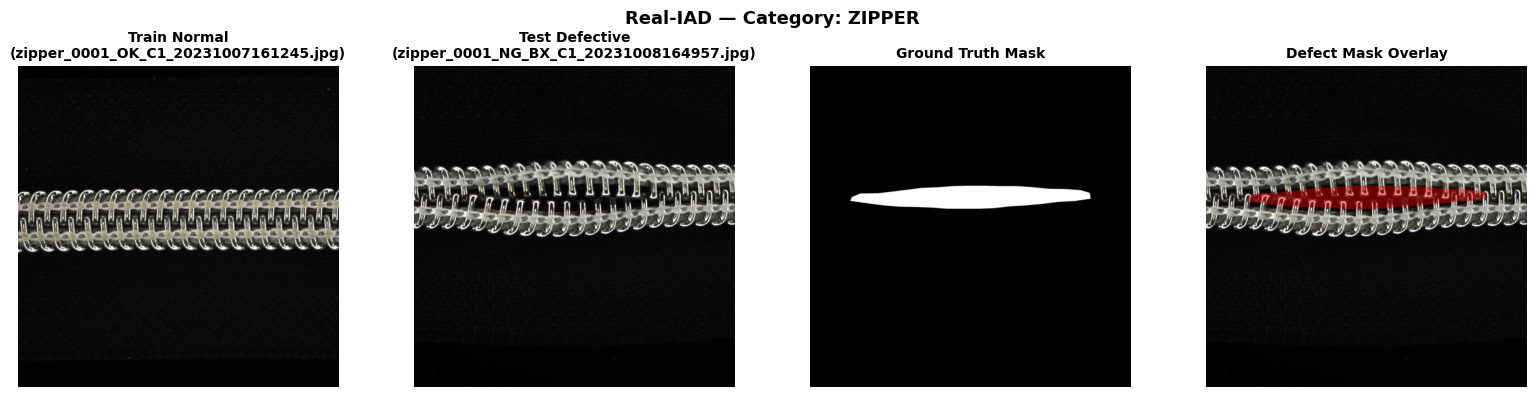

In [5]:
target_cat = "zipper"  # Change this to any valid category name

# 1. Inspect Single-View JSON Metadata Schema
if target_cat in categories:
    inspect_cat = target_cat
    json_inspect_file = json_dir / f"{inspect_cat}.json"

    if json_inspect_file.exists():
        print(f"=== Inspecting Real-IAD Single-View JSON Schema for '{inspect_cat}' ===")
        with open(json_inspect_file, "r") as f:
            meta_inspect = json.load(f)

        print("JSON Structure Type:", type(meta_inspect))

        if isinstance(meta_inspect, dict):
            print("Keys:", list(meta_inspect.keys()))
            for key, value in meta_inspect.items():
                print(f"\nKEY: {key}")
                print(f"TYPE: {type(value)}")
                if isinstance(value, list) and len(value) > 0:
                    print("FIRST ENTRY:", value[0])
                elif isinstance(value, dict):
                    print("FIRST KEYS:", list(value.keys())[:10])
        elif isinstance(meta_inspect, list) and len(meta_inspect) > 0:
            print(f"Total entries: {len(meta_inspect)}")
            print("FIRST ENTRY:", meta_inspect[0])

# 2. Category Samples & Visual Inspection
if target_cat in categories:
    demo_cat = target_cat
    train_demo, test_demo = load_category_samples(demo_cat, image_dir, json_dir)
    print(f"\n=== Real-IAD Category Inspection: '{demo_cat.upper()}' ===")
    print(f"Total Train (Normal) Samples: {len(train_demo)}")

    test_normal_count = sum(1 for s in test_demo if s["label"] == 0)
    test_defect_count = sum(1 for s in test_demo if s["label"] == 1)
    print(f"Total Test Samples:           {len(test_demo)} (Normal: {test_normal_count}, Defective: {test_defect_count})")

    summary_records = [
        {"Category": demo_cat, "Split": "Train", "Type": "Normal", "Count": len(train_demo), "Mask Available": "No"},
        {"Category": demo_cat, "Split": "Test",  "Type": "Normal",   "Count": test_normal_count, "Mask Available": "No"},
        {"Category": demo_cat, "Split": "Test",  "Type": "Defective","Count": test_defect_count, "Mask Available": "Yes"},
    ]
    print("\n" + pd.DataFrame(summary_records).to_string(index=False))

    # Visual Inspection of Demo Category Samples
    defective_candidates = [s for s in test_demo if s["label"] == 1]

    if len(train_demo) > 0 and len(defective_candidates) > 0:
        defect_sample = defective_candidates[0]
        has_mask = defect_sample["mask_path"] is not None and Path(defect_sample["mask_path"]).exists()

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        # 1. Train Normal Image
        train_img_path = train_demo[0]["image_path"] if isinstance(train_demo[0], dict) else train_demo[0]
        with Image.open(train_img_path) as img:
            axes[0].imshow(img.convert("RGB"))
            axes[0].set_title(f"Train Normal\n({Path(train_img_path).name})", fontsize=10, fontweight="bold")
            axes[0].axis("off")

        # 2. Test Defective Image
        with Image.open(defect_sample["image_path"]) as img:
            defect_img_np = np.array(img.convert("RGB"))
            axes[1].imshow(defect_img_np)
            axes[1].set_title(f"Test Defective\n({Path(defect_sample['image_path']).name})", fontsize=10, fontweight="bold")
            axes[1].axis("off")

        # 3. Ground Truth Mask
        if has_mask:
            with Image.open(defect_sample["mask_path"]) as msk:
                msk_np = np.array(msk.convert("L"))
        else:
            msk_np = np.zeros((defect_img_np.shape[0], defect_img_np.shape[1]), dtype=np.uint8)
        axes[2].imshow(msk_np, cmap="gray")
        axes[2].set_title("Ground Truth Mask" + ("" if has_mask else "\n(not available)"), fontsize=10, fontweight="bold")
        axes[2].axis("off")

        # 4. Mask Overlay on Defect Image
        overlay = defect_img_np.copy()
        if overlay.shape[:2] != msk_np.shape[:2]:
            msk_resized = np.array(Image.fromarray(msk_np).resize(
                (overlay.shape[1], overlay.shape[0]), Image.NEAREST))
        else:
            msk_resized = msk_np
        overlay[msk_resized > 128] = [255, 0, 0]
        blended = (0.6 * defect_img_np + 0.4 * overlay).astype(np.uint8)
        axes[3].imshow(blended)
        axes[3].set_title("Defect Mask Overlay", fontsize=10, fontweight="bold")
        axes[3].axis("off")

        plt.suptitle(f"Real-IAD — Category: {demo_cat.upper()}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print(f"[Section 4] Skipping plot: train={len(train_demo)} samples, defective test={len(defective_candidates)} samples.")

# Wide ResNet-50-2 Backbone

In [6]:
class WideResNet50FeatureExtractor(nn.Module):
    """
    Extracts concatenated patch representations from Layer 2 and Layer 3
    of Wide ResNet-50-2 for 512x512 inputs.

    Output: [B, 1536, 64, 64]
    → 4,096 patch feature vectors per image.
    """
    def __init__(self, resnet):
        super().__init__()

        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1
        )

        self.layer2 = resnet.layer2  # [B, 512, 64, 64]
        self.layer3 = resnet.layer3  # [B, 1024, 32, 32]

        self.avg_pool = nn.AvgPool2d(
            kernel_size=3,
            stride=1,
            padding=1
        )

    def forward(self, x):
        x = self.stem(x)

        f2 = self.layer2(x)
        f3 = self.layer3(f2)

        f2 = self.avg_pool(f2)
        f3 = self.avg_pool(f3)

        f3 = F.interpolate(
            f3,
            size=f2.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return torch.cat([f2, f3], dim=1)


print("\nLoading pretrained Wide ResNet-50-2 backbone...")
weights = Wide_ResNet50_2_Weights.DEFAULT
base_model = wide_resnet50_2(weights=weights)

for param in base_model.parameters():
    param.requires_grad = False

base_feature_extractor = WideResNet50FeatureExtractor(base_model)

# Wrap with DataParallel if multiple GPUs (e.g. 2x T4) are available
if num_gpus > 1:
    print(f"Wrapping backbone in nn.DataParallel to utilize all {num_gpus} GPUs (cuda:0, cuda:1)...")
    backbone = nn.DataParallel(base_feature_extractor, device_ids=list(range(num_gpus)))
else:
    backbone = base_feature_extractor

backbone = backbone.to(device)
backbone.eval()


Loading pretrained Wide ResNet-50-2 backbone...
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:01<00:00, 184MB/s]  


Wrapping backbone in nn.DataParallel to utilize all 2 GPUs (cuda:0, cuda:1)...


DataParallel(
  (module): WideResNet50FeatureExtractor(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): R

# Evaluation Metrics: S-AUROC, I-AUROC, and P-AUPRO Functions

In [7]:
def compute_patch_min_distances(patches, mem_bank, chunk_size=256):
    """
    Computes minimum Euclidean distance from each patch vector to the memory bank.
    Uses chunking to control VRAM usage during nearest-neighbor distance computation.
    
    patches:  [B, num_patches, 1536]
    mem_bank: [M, 1536]
    returns:  [B, num_patches]
    """
    B, num_patches, C = patches.shape
    patches_flat = patches.reshape(-1, C)
    min_dists = []
    
    for i in range(0, patches_flat.shape[0], chunk_size):
        chunk = patches_flat[i : i + chunk_size]
        # Distance matrix for chunk: [chunk_size, M]
        dists = torch.cdist(chunk, mem_bank)
        min_dists.append(dists.min(dim=1).values)
        
    return torch.cat(min_dists).reshape(B, num_patches)


def calculate_aupro(gt_masks_list, pred_maps_list, max_fpr=0.30, num_thresholds=100):
    """
    Computes Per-Region Overlap Area Under the Curve (P-AUPRO) up to max_fpr (0.30).
    Conforms to standard industrial anomaly localization benchmarks.
    
    gt_masks_list:  list of 2D numpy arrays (binary: 0 or 1)
    pred_maps_list: list of 2D numpy arrays (continuous anomaly scores)
    """
    if len(gt_masks_list) == 0 or sum(np.sum(m) for m in gt_masks_list) == 0:
        return 0.0

    all_scores = np.concatenate([p.ravel() for p in pred_maps_list])
    min_score, max_score = np.min(all_scores), np.max(all_scores)
    
    if min_score == max_score:
        return 0.0

    thresholds = np.linspace(min_score, max_score, num_thresholds)
    
    # Pre-extract connected components for ground truth masks
    labeled_regions = []
    for gt in gt_masks_list:
        labeled, num_features = nd_label(gt > 0.5)
        labeled_regions.append((labeled, num_features))

    total_normal_pixels = sum(np.sum(gt <= 0.5) for gt in gt_masks_list)
    if total_normal_pixels == 0:
        return 0.0

    fpr_list = []
    pro_list = []

    for t in thresholds:
        fp_pixels = 0
        region_pro_sum = 0.0
        total_regions = 0

        for i, (pred, (labeled, num_features)) in enumerate(zip(pred_maps_list, labeled_regions)):
            pred_binary = (pred >= t)
            gt = gt_masks_list[i]
            
            # False Positive pixels on normal background
            fp_pixels += np.sum(pred_binary & (gt <= 0.5))

            # Per-region overlap calculation
            for region_idx in range(1, num_features + 1):
                region_mask = (labeled == region_idx)
                region_size = np.sum(region_mask)
                overlap = np.sum(pred_binary & region_mask)
                region_pro_sum += overlap / region_size
                total_regions += 1

        fpr = fp_pixels / total_normal_pixels
        pro = (region_pro_sum / total_regions) if total_regions > 0 else 0.0

        fpr_list.append(fpr)
        pro_list.append(pro)

    pairs = sorted(
        zip(fpr_list, pro_list),
        key=lambda x: x[0]
    )

    limited_pairs = [
        (fpr, pro)
        for fpr, pro in pairs
        if fpr <= max_fpr
    ]

    if len(limited_pairs) < 2:
        return 0.0

    fpr_limited = np.array([x[0] for x in limited_pairs])
    pro_limited = np.array([x[1] for x in limited_pairs])

    # Trapezoidal integration normalized by max_fpr (supports numpy 1.x & 2.x)
    trapz_fn = getattr(np, "trapezoid", np.trapz)
    aupro = trapz_fn(pro_limited, fpr_limited) / max_fpr

    return float(np.clip(aupro, 0.0, 1.0))

# Category-by-Category Training & Testing Pipeline

In [8]:
# Hyperparameters
batch_size = 8           # Conservative batch size for 512x512 resolution
sampling_ratio = 0.01    # 1% PatchCore subsampling (approx 4,000-8,000 vectors per category)
val_split_ratio = 0.20   # 20% held-out normal images for threshold determination

# Result containers
category_memory_banks = {}
category_thresholds = {}
image_evaluation_results = {}
pixel_evaluation_results = {}
all_test_predictions = {}

print("\n" + "=" * 80)
print(f"STARTING REAL-IAD EVALUATION (Categories: {len(categories)}, Resolution: 512x512, Multi-GPU: {num_gpus > 1})")
print("=" * 80)

for cat_idx, cat in enumerate(categories, start=1):
    print(f"\n[{cat_idx}/{len(categories)}] Processing Category: '{cat}'")
    
    # 1. Load category sample manifests
    train_samples, test_samples = load_category_samples(cat, image_dir, json_dir)
    if len(train_samples) == 0:
        print(f"  [Skipping] No training samples found for category '{cat}'.")
        continue

    # 2. Split training normals into memory-bank subset and held-out validation set
    random.shuffle(train_samples)
    split_idx = max(1, int(len(train_samples) * (1.0 - val_split_ratio)))
    mem_train_samples = train_samples[:split_idx]
    val_norm_samples = train_samples[split_idx:] if split_idx < len(train_samples) else train_samples[:1]

    # 3. Create PyTorch DataLoaders (pin_memory=False to prevent host RAM locking)
    train_ds = TrainDataset(mem_train_samples, transform=image_transform)
    val_ds = TrainDataset(val_norm_samples, transform=image_transform)
    test_ds = TestDataset(
        images=[s["image_path"] for s in test_samples],
        labels=[s["label"] for s in test_samples],
        masks=[s["mask_path"] for s in test_samples],
        img_transform=image_transform,
        msk_transform=mask_transform
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)

    print(f"  Train (Mem Bank): {len(mem_train_samples)} | Val (Threshold): {len(val_norm_samples)} | Test: {len(test_samples)}")

    # 4. Extract & Stream-Subsample Feature Vectors On-The-Fly (Prevents 10+ GB RAM allocation)
    train_patch_list = []
    total_raw_patches = 0
    with torch.no_grad():
        for batch_imgs in train_loader:
            batch_imgs = batch_imgs.to(device)
            feats = backbone(batch_imgs)  # [B, 1536, 64, 64]
            assert feats.shape[1:] == (1536, 64, 64), \
                f"Unexpected feature shape: {feats.shape}"
            B_f, C_f, H_f, W_f = feats.shape
            patches = feats.permute(0, 2, 3, 1).reshape(-1, C_f)
            total_raw_patches += patches.shape[0]

            # Randomly retain 1% of patches from each batch to avoid storing
            # the full category feature matrix in CPU RAM.
            num_b_samples = max(1, int(patches.shape[0] * sampling_ratio))
            idx = torch.randperm(patches.shape[0], device=patches.device)[:num_b_samples]
            train_patch_list.append(patches[idx].cpu())

    cat_mem_bank = torch.cat(train_patch_list, dim=0).to(device)
    
    # Store memory bank on CPU in dictionary to preserve GPU VRAM
    category_memory_banks[cat] = cat_mem_bank.cpu()
    print(f"  Memory Bank shape: {cat_mem_bank.shape} (sampled from {total_raw_patches} patches)")

    # 5. Compute Validation Threshold using Held-Out Normal Images
    val_scores = []
    with torch.no_grad():
        for batch_imgs in val_loader:
            batch_imgs = batch_imgs.to(device)
            feats = backbone(batch_imgs)
            B_v, C_v, H_v, W_v = feats.shape
            val_patches = feats.permute(0, 2, 3, 1).reshape(B_v, H_v * W_v, C_v)
            val_min_dist = compute_patch_min_distances(val_patches, cat_mem_bank, chunk_size=256)
            val_scores.append(val_min_dist.max(dim=1).values.cpu())

    all_val_scores = torch.cat(val_scores)
    cat_threshold = torch.quantile(all_val_scores.float(), 0.99).item()
    category_thresholds[cat] = cat_threshold
    print(f"  Validation 99th-Percentile Anomaly Threshold: {cat_threshold:.4f}")

    # 6. Test Set Inference (Image-level Scores and 64x64 Anomaly Maps)
    test_scores = []
    test_maps_64 = []
    test_labels_list = []
    test_masks_512 = []

    with torch.no_grad():
        for batch_imgs, batch_lbls, batch_msks in test_loader:
            batch_imgs = batch_imgs.to(device)
            feats = backbone(batch_imgs)
            B_t, C_t, H_t, W_t = feats.shape
            test_patches = feats.permute(0, 2, 3, 1).reshape(B_t, H_t * W_t, C_t)
            
            min_dist = compute_patch_min_distances(test_patches, cat_mem_bank, chunk_size=256)
            
            # Image score = max patch distance
            score = min_dist.max(dim=1).values.cpu()
            # Spatial anomaly map: [B, 64, 64]
            amap = min_dist.reshape(B_t, H_t, W_t).cpu()

            test_scores.append(score)
            test_maps_64.append(amap)
            test_labels_list.append(batch_lbls)
            # Store masks as uint8 (1 byte per pixel) to save 75% RAM
            test_masks_512.append((batch_msks.squeeze(1) > 0.5).to(torch.uint8))

    cat_test_scores = torch.cat(test_scores).numpy()
    cat_test_maps_64 = torch.cat(test_maps_64)
    cat_test_labels = torch.cat(test_labels_list).numpy()
    cat_test_masks = torch.cat(test_masks_512).numpy()  # uint8 array

    # 7. Upsample Anomaly Maps to 512x512 for Pixel Evaluation
    cat_test_maps_512 = F.interpolate(
        cat_test_maps_64.unsqueeze(1),
        size=(input_size, input_size),
        mode="bilinear",
        align_corners=False
    ).squeeze(1).numpy()

    # 8. Compute Sample-Level Metrics (S-AUROC, Accuracy, Precision, Recall, F1)
    if len(np.unique(cat_test_labels)) > 1:
        s_auroc = roc_auc_score(cat_test_labels, cat_test_scores)
    else:
        s_auroc = 1.0

    y_pred = (cat_test_scores >= cat_threshold).astype(int)
    acc = accuracy_score(cat_test_labels, y_pred)
    prec = precision_score(cat_test_labels, y_pred, zero_division=0)
    rec = recall_score(cat_test_labels, y_pred, zero_division=0)
    f1 = f1_score(cat_test_labels, y_pred, zero_division=0)

    image_evaluation_results[cat] = {
        "S-AUROC": s_auroc,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Threshold": cat_threshold,
    }

    # 9. Compute Pixel-Level Localization Metrics (I-AUROC & P-AUPRO)
    y_true_pixel = cat_test_masks.ravel()
    y_scores_pixel = cat_test_maps_512.ravel()

    if len(np.unique(y_true_pixel)) > 1:
        i_auroc = roc_auc_score(y_true_pixel, y_scores_pixel)
        p_aupro = calculate_aupro(list(cat_test_masks), list(cat_test_maps_512), max_fpr=0.30)
    else:
        i_auroc = 1.0
        p_aupro = 1.0

    pixel_evaluation_results[cat] = {
        "I-AUROC (Pixel)": i_auroc,
        "P-AUPRO (0.30)": p_aupro,
        "Threshold": cat_threshold,
    }

    print(f"  -> S-AUROC: {s_auroc:.4f} | I-AUROC: {i_auroc:.4f} | P-AUPRO: {p_aupro:.4f} | F1: {f1:.4f}")

    # 10. Keep full-resolution maps only for the first 3 categories
    # to avoid accumulating large prediction arrays in RAM.
    if cat_idx <= 3:
        all_test_predictions[cat] = {
            "scores":      cat_test_scores,
            "labels":      cat_test_labels,
            "maps_512":    cat_test_maps_512,
            "masks":       cat_test_masks,
            "image_paths": [s["image_path"] for s in test_samples],
        }

    # Free memory and force garbage collection after each category
    del train_patch_list, cat_mem_bank, cat_test_maps_64
    if cat_idx > 3:
        del cat_test_maps_512, cat_test_masks
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


STARTING REAL-IAD EVALUATION (Categories: 30, Resolution: 512x512, Multi-GPU: True)

[1/30] Processing Category: 'audiojack'
  Train (Mem Bank): 319 | Val (Threshold): 80 | Test: 611
  Memory Bank shape: torch.Size([13039, 1536]) (sampled from 1306624 patches)
  Validation 99th-Percentile Anomaly Threshold: 21.4030
  -> S-AUROC: 0.8288 | I-AUROC: 0.9944 | P-AUPRO: 0.9451 | F1: 0.7821

[2/30] Processing Category: 'bottle_cap'
  Train (Mem Bank): 296 | Val (Threshold): 74 | Test: 633
  Memory Bank shape: torch.Size([12099, 1536]) (sampled from 1212416 patches)
  Validation 99th-Percentile Anomaly Threshold: 18.1935
  -> S-AUROC: 0.9618 | I-AUROC: 0.9966 | P-AUPRO: 0.8929 | F1: 0.7435

[3/30] Processing Category: 'button_battery'
  Train (Mem Bank): 233 | Val (Threshold): 59 | Test: 708
  Memory Bank shape: torch.Size([9523, 1536]) (sampled from 954368 patches)
  Validation 99th-Percentile Anomaly Threshold: 20.8063
  -> S-AUROC: 0.8479 | I-AUROC: 0.9947 | P-AUPRO: 0.9163 | F1: 0.6912

[

# Evaluation Summary Reports

In [9]:
print("\n" + "=" * 80)
print("=== REAL-IAD SAMPLE-LEVEL EVALUATION (S-AUROC) ===")
print("=" * 80)
image_df = pd.DataFrame(image_evaluation_results).T
print(image_df.round(4).to_string())

print("\n=== MEAN SAMPLE-LEVEL METRICS ===")
print(image_df[["S-AUROC", "Accuracy", "Precision", "Recall", "F1-Score"]].mean().round(4).to_string())

print("\n" + "=" * 80)
print("=== REAL-IAD PIXEL-LEVEL LOCALIZATION EVALUATION (I-AUROC & P-AUPRO) ===")
print("=" * 80)
pixel_df = pd.DataFrame(pixel_evaluation_results).T
print(pixel_df.round(4).to_string())

print("\n=== MEAN PIXEL-LEVEL METRICS ===")
print(pixel_df[["I-AUROC (Pixel)", "P-AUPRO (0.30)"]].mean().round(4).to_string())


=== REAL-IAD SAMPLE-LEVEL EVALUATION (S-AUROC) ===
                   S-AUROC  Accuracy  Precision  Recall  F1-Score  Threshold
audiojack           0.8288    0.8723     0.9655  0.6573    0.7821    21.4030
bottle_cap          0.9618    0.8278     0.9814  0.5985    0.7435    18.1935
button_battery      0.8479    0.7161     0.9615  0.5396    0.6912    20.8063
end_cap             0.8329    0.6732     0.8631  0.5354    0.6608    19.3390
eraser              0.9379    0.8638     0.9870  0.6468    0.7815    19.8173
fire_hood           0.9596    0.9114     0.9034  0.7751    0.8344    22.4464
mint                0.7268    0.5762     0.8963  0.3267    0.4788    18.7771
mounts              0.9264    0.7920     0.9661  0.4750    0.6369    22.7317
pcb                 0.9023    0.6224     0.9674  0.4000    0.5660    21.3793
phone_battery       0.9362    0.8015     0.9943  0.5748    0.7284    22.0916
plastic_nut         0.8607    0.8339     0.7551  0.3136    0.4431    21.0721
plastic_plug        0.95

# Qualitative Visualizations


GENERATING QUALITATIVE DEFECT LOCALIZATION VISUALIZATIONS


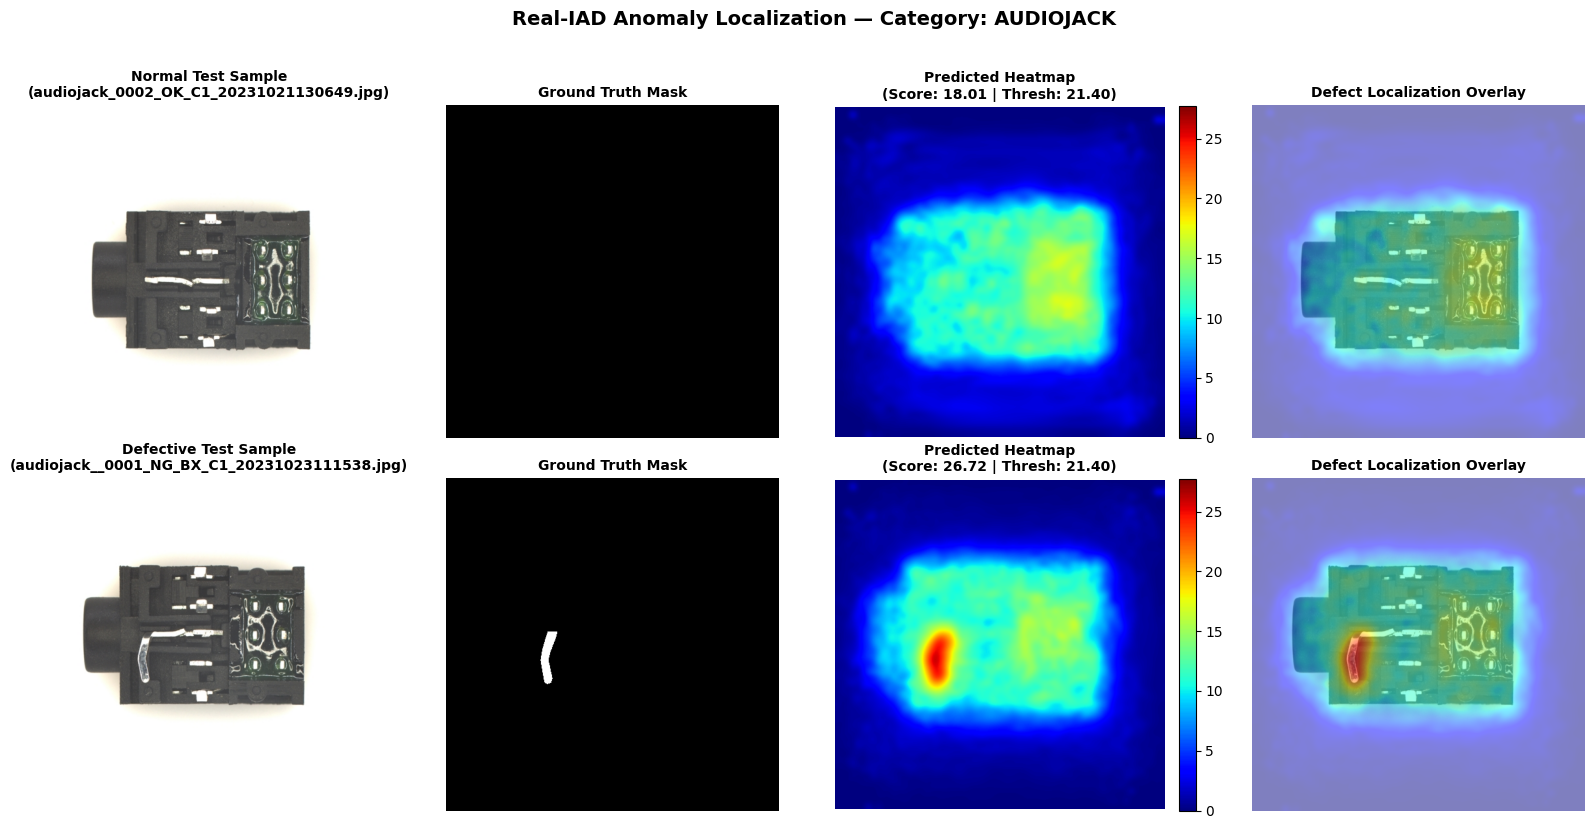

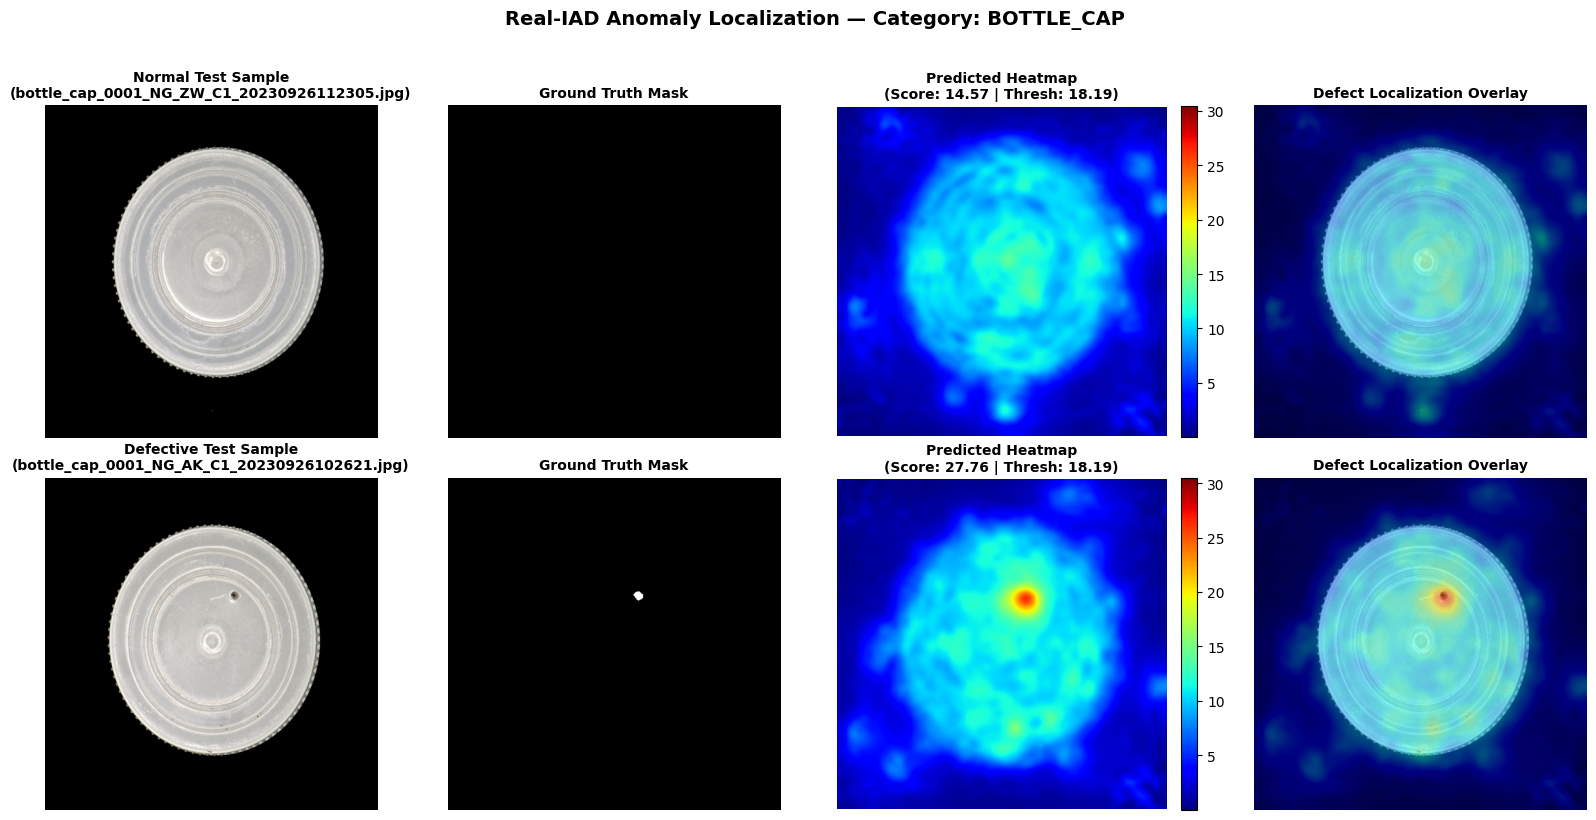

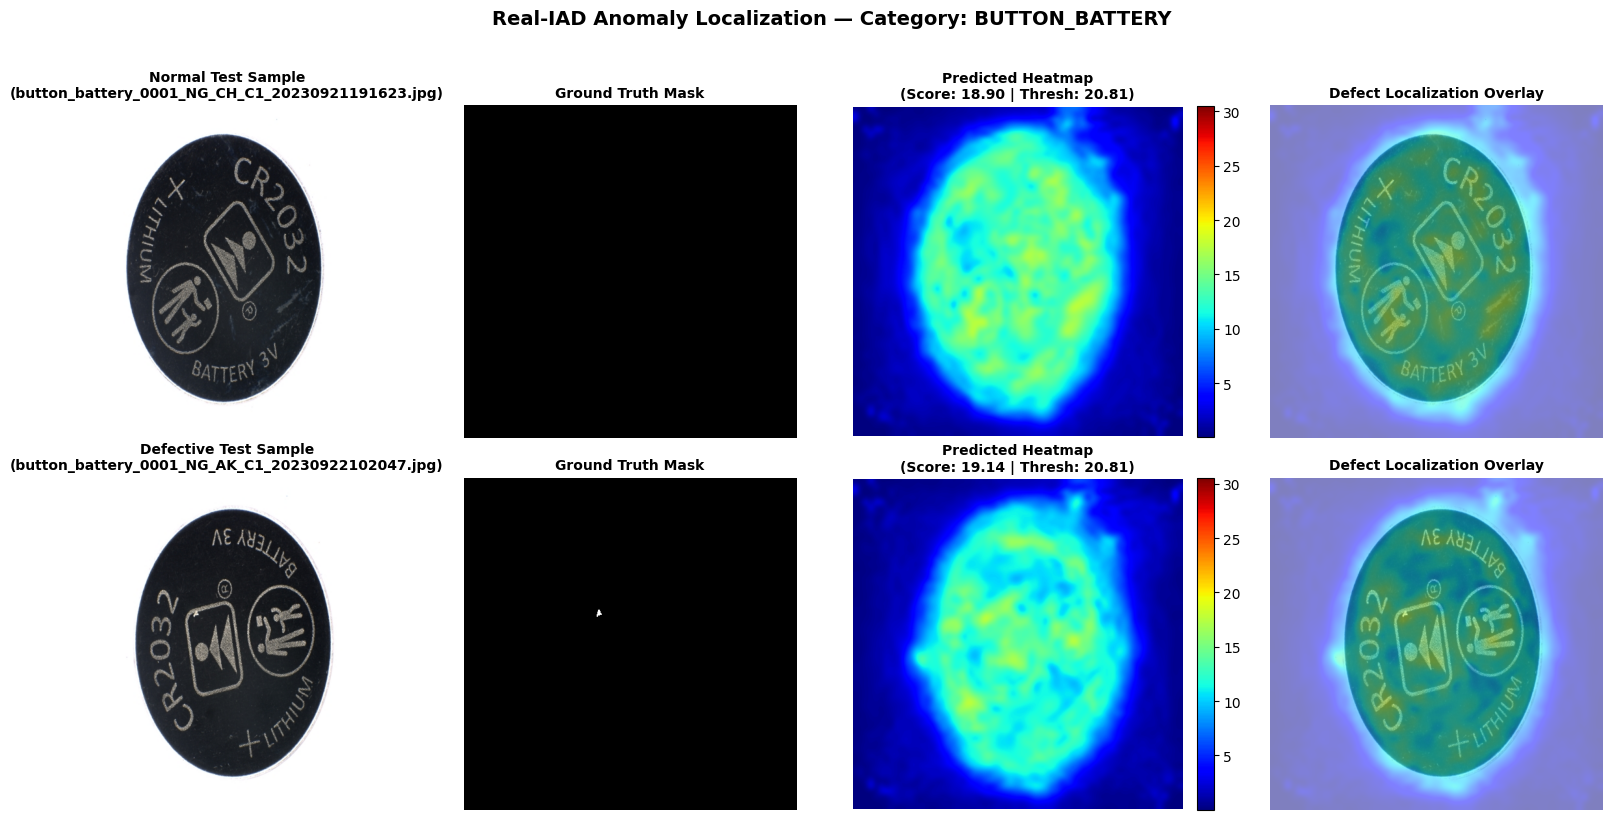

In [10]:
print("\n" + "=" * 80)
print("GENERATING QUALITATIVE DEFECT LOCALIZATION VISUALIZATIONS")
print("=" * 80)

for cat in list(all_test_predictions.keys())[:3]:  # Visualize first 3 categories
    cat_preds = all_test_predictions[cat]
    scores = cat_preds["scores"]
    labels = cat_preds["labels"]
    maps_512 = cat_preds["maps_512"]
    masks = cat_preds["masks"]
    thresh = category_thresholds[cat]

    normal_indices = np.where(labels == 0)[0]
    defect_indices = np.where(labels == 1)[0]

    selected_indices = []
    if len(normal_indices) > 0:
        selected_indices.append(("Normal Test Sample", normal_indices[0]))
    if len(defect_indices) > 0:
        selected_indices.append(("Defective Test Sample", defect_indices[0]))

    if not selected_indices:
        continue

    fig, axes = plt.subplots(len(selected_indices), 4, figsize=(16, 4 * len(selected_indices)))
    if len(selected_indices) == 1:
        axes = np.expand_dims(axes, 0)
    fig.suptitle(f"Real-IAD Anomaly Localization — Category: {cat.upper()}", fontsize=14, fontweight="bold", y=1.02)

    # Smooth maps using Gaussian blur for clean visual display
    raw_tensor = torch.from_numpy(maps_512).unsqueeze(1)
    smoothed_maps = TF.gaussian_blur(raw_tensor, kernel_size=(33, 33), sigma=(4.0, 4.0)).squeeze(1).numpy()
    v_min, v_max = smoothed_maps.min(), smoothed_maps.max()

    for row, (sample_title, s_idx) in enumerate(selected_indices):
        sample_img_path = cat_preds["image_paths"][s_idx]

        with Image.open(sample_img_path) as img:
            orig_rgb = np.array(img.convert("RGB").resize((input_size, input_size))) / 255.0

        gt_mask = masks[s_idx]
        amap = smoothed_maps[s_idx]
        amap_norm = np.clip((amap - v_min) / (v_max - v_min + 1e-8), 0.0, 1.0)
        heatmap_rgb = plt.cm.jet(amap_norm)[..., :3]
        overlay = np.clip(0.5 * orig_rgb + 0.5 * heatmap_rgb, 0.0, 1.0)

        # Column 1: Original Image
        axes[row, 0].imshow(orig_rgb)
        axes[row, 0].set_title(f"{sample_title}\n({Path(sample_img_path).name})", fontsize=10, fontweight="bold")
        axes[row, 0].axis("off")

        # Column 2: Ground Truth Mask
        axes[row, 1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground Truth Mask", fontsize=10, fontweight="bold")
        axes[row, 1].axis("off")

        # Column 3: Predicted Heatmap
        im = axes[row, 2].imshow(amap, cmap="jet", vmin=v_min, vmax=v_max)
        axes[row, 2].set_title(f"Predicted Heatmap\n(Score: {scores[s_idx]:.2f} | Thresh: {thresh:.2f})", fontsize=10, fontweight="bold")
        axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

        # Column 4: Heatmap Overlay
        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title("Defect Localization Overlay", fontsize=10, fontweight="bold")
        axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()

# Save Model Artifacts

In [13]:
# Extract unwrapped state dict from backbone if using DataParallel
if isinstance(backbone, nn.DataParallel):
    backbone_to_save = backbone.module
else:
    backbone_to_save = backbone

# Move backbone weights to CPU before serialization
backbone_state_dict = {
    k: v.cpu()
    for k, v in backbone_to_save.state_dict().items()
}

realiad_artifacts = {
    # Method
    "method": "PatchCore-style anomaly detection",
    "dataset": "Real-IAD",
    "version": "1.0",

    # Backbone
    "backbone": "WideResNet50_2",
    "backbone_variant": "wide_resnet50_2",
    "pretrained_weights": "ImageNet",
    "feature_layers": ["layer2", "layer3"],

    # Categories
    "categories": list(categories),

    # Learned category-specific artifacts
    "memory_banks": category_memory_banks,
    "thresholds": category_thresholds,

    # Backbone weights
    "backbone_state_dict": backbone_state_dict,

    # Feature representation
    "feature_dim": 1536,
    "feature_map_size": 64,
    "input_size": 512,

    # PatchCore configuration
    "sampling_ratio": sampling_ratio,
    "memory_bank_sampling": "random",
    "distance_metric": "euclidean",
    "score_method": "max_patch_min_distance",

    # Memory-bank metadata
    "memory_bank_size": {
        cat: len(bank)
        for cat, bank in category_memory_banks.items()
    },

    # ImageNet preprocessing
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],

    # Visualization parameters
    "gaussian_kernel": 33,
    "gaussian_sigma": 4.0,
}

save_path = "realiad_patchcore_model.pt"

torch.save(realiad_artifacts, save_path)

print("\n" + "=" * 80)
print("ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 80)
print(f"Path:               {save_path}")
print(f"Categories included: {len(realiad_artifacts['categories'])}")
print(f"Feature dimension:   {realiad_artifacts['feature_dim']}")
print(f"Input size:          {realiad_artifacts['input_size']}x{realiad_artifacts['input_size']}")
print(f"Model file size:     {os.path.getsize(save_path) / (1024 * 1024):.2f} MB")
print("=" * 80)


ARTIFACTS SAVED SUCCESSFULLY
Path:               realiad_patchcore_model.pt
Categories included: 30
Feature dimension:   1536
Input size:          512x512
Model file size:     2086.24 MB
